# **Rock Digital Phantom**

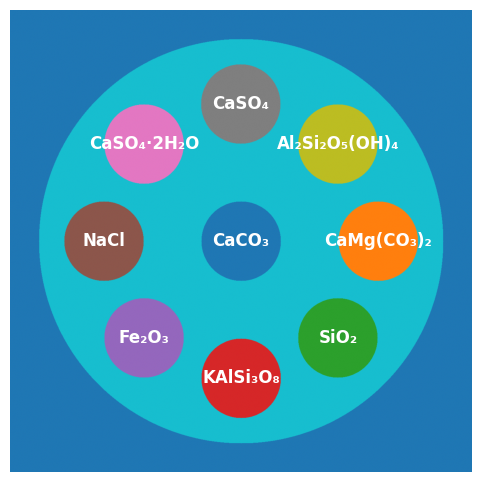

In [2]:
# @title
import numpy as np
import pandas as pd
import itertools
import tifffile as tiff
import matplotlib.pyplot as plt

# Image geometry
IMG_SIZE = 1280
XC, YC = 640, 640

# Radii (pixels)
MAIN_RADIUS = 560
INCLUSION_RADIUS = 110
RING_RADIUS = 380

#Material Labels
# Changed 'materials' from a set to a dictionary (integer label -> string name)
# for consistency with how it's used to assign labels and for plotting.

material = {
    1: "CaCO₃",             # Calcite
    2: "CaMg(CO₃)₂",        # Dolomite
    3: "SiO₂",              # Quartz
    4: "KAlSi₃O₈",          # Potassium Feldspar (Orthoclase)
    5: "Fe₂O₃",             # Hematite
    6: "NaCl",              # Halite
    7: "CaSO₄·2H₂O",        # Gypsum
    8: "CaSO₄",             # Anhydrite
    9: "Al₂Si₂O₅(OH)₄",     # Kaolinite
}

# ============================================================
# AUTO-GENERATE CENTERS (DYNAMIC RING LAYOUT)
# ============================================================

# Keep CaCO3 fixed at center (label 1)
center_label = 1

# Get all other labels except center
# Now 'materials' is a dictionary, .keys() is valid and returns integer labels
ring_labels = [lbl for lbl in material.keys() if lbl != center_label]

num_points = len(ring_labels)

centers = {}

# Center material
centers[center_label] = (XC, YC)

# Generate circular positions
angles = np.linspace(0, 2*np.pi, num_points, endpoint=False)

for lbl, theta in zip(ring_labels, angles):
    cx = int(XC + RING_RADIUS * np.cos(theta))
    cy = int(YC + RING_RADIUS * np.sin(theta))
    centers[lbl] = (cx, cy)

# Initialize label image
label_img = np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.uint8)

# Coordinate grid
Y, X = np.ogrid[:IMG_SIZE, :IMG_SIZE]

# Main phantom mask
phantom_label = 11  # new label for phantom body (not 0, not in 1-10)
main_mask = (X - XC)**2 + (Y - YC)**2 <= MAIN_RADIUS**2
label_img[main_mask] = phantom_label  # background inside phantom

# Add inclusions
for label, (cx, cy) in centers.items():
    mask = (X - cx)**2 + (Y - cy)**2 <= INCLUSION_RADIUS**2
    label_img[mask] = label

np.save("Rock Synthetic Phantom.npy", label_img)

#Plot Material Lables
plt.figure(figsize=(6,6))
plt.imshow(label_img, cmap='tab10')
plt.axis("off")

# Removed redundant 'material_names' dictionary as 'materials' now serves this purpose.
# The original 'material_names' dictionary was identical to the corrected 'materials' dictionary.

for label, (x, y) in centers.items():
    plt.text(x, y, material [label],
             color='white', fontsize=12,fontweight="bold",
             ha='center', va='center')


plt.savefig(
    "Rock Synthetic Phantom.png",
    dpi=600,
    bbox_inches='tight',
    pad_inches=0
)
#plt.title("Rock Synthetic Phantom")
#plt.colorbar(label="Rock Compound Label")
plt.show()

In [3]:
# @title
# ============================================================
# SPCCT Image Generation (Single Excel, Gaussian μ + k)
# ============================================================

import numpy as np
import pandas as pd
import tifffile as tiff
from scipy.stats import truncnorm

excel_path = "GD Parameters with Inverse Calibrated wLAC - BUHASA Compounds.xlsx"
num_bins = 5
images = []

k_bins = np.array([0.130, 0.128, 0.130, 0.128, 0.117])

mu_cols = ["wLAC_1", "wLAC_2", "wLAC_3", "wLAC_4", "wLAC_5"]

# ------------------------------------------------------------
# Make sure phantom label is included
# ------------------------------------------------------------
material = {
    1: "CaCO₃",             # Calcite
    2: "CaMg(CO₃)₂",        # Dolomite
    3: "SiO₂",              # Quartz
    4: "KAlSi₃O₈",          # Potassium Feldspar (Orthoclase)
    5: "Fe₂O₃",             # Hematite
    6: "NaCl",              # Halite
    7: "CaSO₄·2H₂O",        # Gypsum
    8: "CaSO₄",             # Anhydrite
    9: "Al₂Si₂O₅(OH)₄",     # Kaolinite
    11: "Phantom"           #PMMA
}

# ------------------------------------------------------------
# LOAD EXCEL
# ------------------------------------------------------------
df = pd.read_excel(excel_path)

mu_table = {}

for _, row in df.iterrows():
    compound_name = row["Compound"]
    mu_values = row[mu_cols].values.astype(float)
    mu_table[compound_name] = mu_values

# ------------------------------------------------------------
# GENERATE IMAGES
# ------------------------------------------------------------
for e in range(num_bins):

    img = np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.float32)

    for label, compound_name in material.items():

        if compound_name not in mu_table:
            raise ValueError(f"{compound_name} not found in Excel")

        mask = label_img == label
        N = mask.sum()

        if N == 0:
            continue

        mu = mu_table[compound_name][e]
        sigma = k_bins[e] * mu

        #vals = np.random.normal(mu, sigma, size=N)
        #vals = np.clip(vals, 0, None)

        lower = mu - 3*sigma
        upper = mu + 3*sigma
        a = (lower - mu) / sigma
        b = (upper - mu) / sigma
        vals = truncnorm.rvs(
        a, b,
        loc=mu,
        scale=sigma,
        size=N
        )

        img[mask] = vals

    images.append(img)

spcct_image = np.stack(images, axis=0)

tiff.imwrite(
    "Rocks Synthetic Phantom.tiff",
    spcct_image.astype(np.float32)
)

print("✅ Saved: Rocks Synthetic Phantom.tiff")
print("Shape:", spcct_image.shape)
print("Min:", spcct_image.min())
print("Max:", spcct_image.max())

✅ Saved: Rocks Synthetic Phantom.tiff
Shape: (5, 1280, 1280)
Min: 0.0
Max: 8.118825


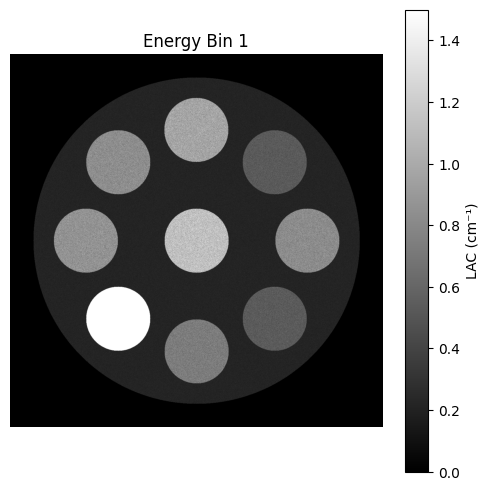

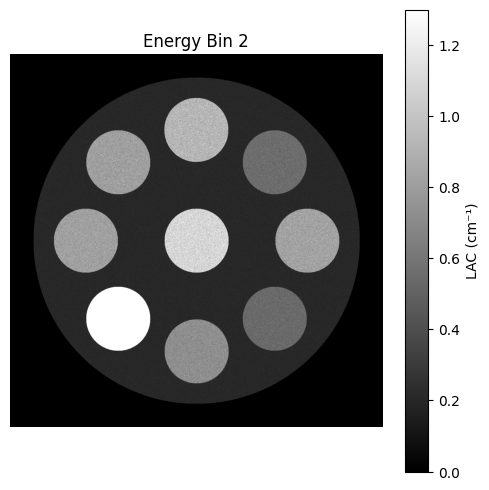

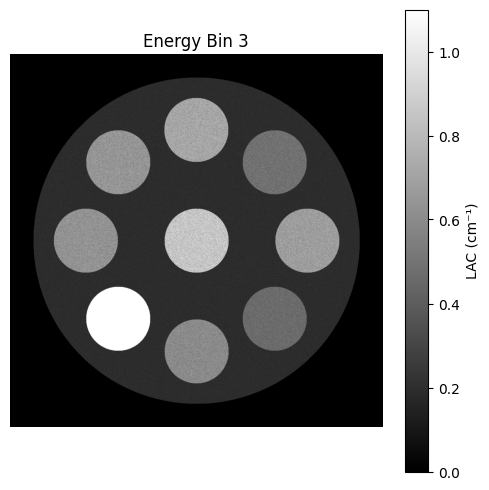

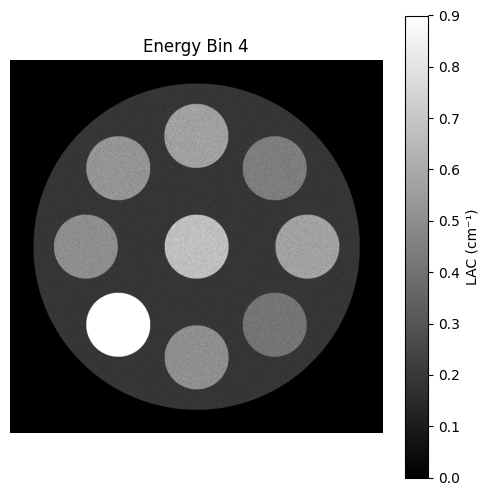

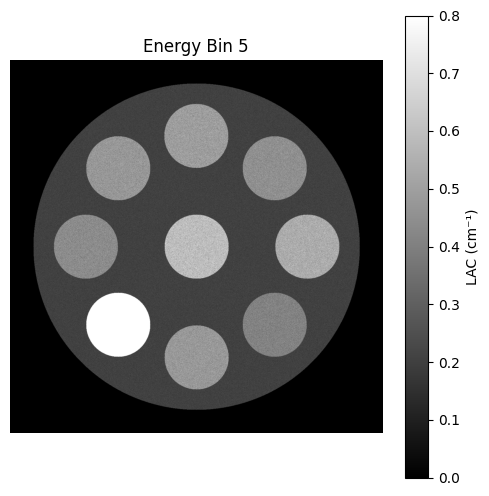

In [4]:
vmax_bins = [1.5, 1.3, 1.1, 0.9, 0.8]

for b in range(5):

    plt.figure(figsize=(6,6))

    plt.imshow(
        spcct_image[b],
        cmap="gray",
        vmin=0,
        vmax=vmax_bins[b]
    )

    plt.title(f"Energy Bin {b+1}")
    plt.axis("off")
    plt.colorbar(label="LAC (cm⁻¹)")

    plt.show()

**saving each bin separately**

In [ ]:
# @title
# ------------------------------------------------------------
# Save each energy bin as a separate TIFF image
# ------------------------------------------------------------

import os
import numpy as np
import tifffile as tiff

output_dir = "Rocks_Synthetic_Phantom_Bins"

os.makedirs(output_dir, exist_ok=True)

for b in range(spcct_image.shape[0]):  # spcct_image shape = (5, H, W)

    bin_img = spcct_image[b].astype(np.float32)

    # Optional: clip values before saving
    # bin_img = np.clip(bin_img, 0, 1.5)

    filename = os.path.join(
        output_dir,
        f"Rocks_Synthetic_Phantom_Bin{b+1}.tiff"
    )

    tiff.imwrite(filename, bin_img)

    print(f"✅ Saved: {filename}")

print("\n✅ All energy bins saved as separate TIFF files.")
print("Saved in folder:", os.path.abspath(output_dir))

✅ Saved: Rocks_Synthetic_Phantom_Bins/Rocks_Synthetic_Phantom_Bin1.tiff
✅ Saved: Rocks_Synthetic_Phantom_Bins/Rocks_Synthetic_Phantom_Bin2.tiff
✅ Saved: Rocks_Synthetic_Phantom_Bins/Rocks_Synthetic_Phantom_Bin3.tiff
✅ Saved: Rocks_Synthetic_Phantom_Bins/Rocks_Synthetic_Phantom_Bin4.tiff
✅ Saved: Rocks_Synthetic_Phantom_Bins/Rocks_Synthetic_Phantom_Bin5.tiff

✅ All energy bins saved as separate TIFF files.
Saved in folder: /content/Rocks_Synthetic_Phantom_Bins


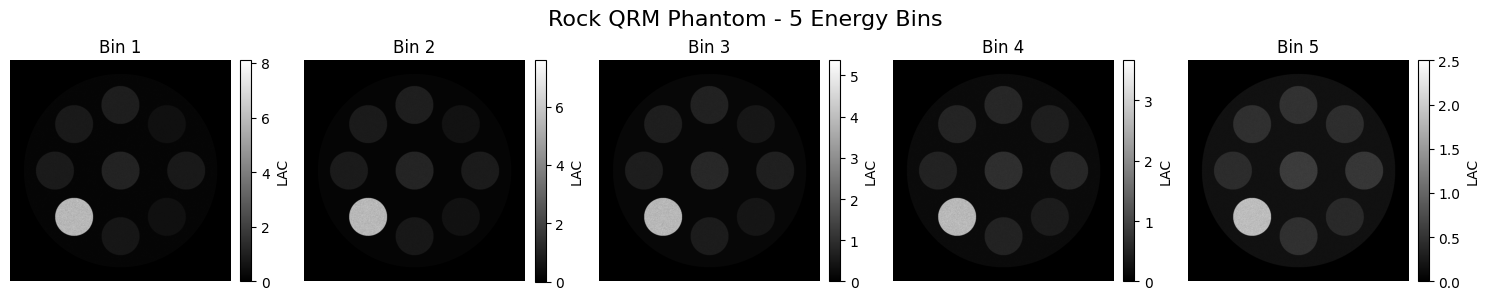

In [ ]:
# @title
import matplotlib.pyplot as plt

# ----------------------------
# Display all 5 energy bins
# ----------------------------
plt.figure(figsize=(15, 3))  # wide figure

for e in range(num_bins):
    plt.subplot(1, num_bins, e+1)
    plt.imshow(spcct_image[e], cmap='gray')  # or 'gray'
    plt.title(f'Bin {e+1}')
    plt.axis('off')
    plt.colorbar(fraction=0.046, pad=0.04, label='LAC')

plt.suptitle("Rock QRM Phantom - 5 Energy Bins", fontsize=16)
plt.tight_layout()
plt.show()

# **Rock Phantom ED & Zeff Map**

Stack Shape: (5, 1280, 1280)
Calibration Applied
Calibrated image saved
mu_low min/max: -0.1077 13.685647322273255
mu_high min/max: -0.0077 2.5657168293952943
Valid ratio min: 0.4570721250140114
Valid ratio max: 9.932728046260527
Calculating Zeff map...
Zeff Calculation Complete
Zeff map saved


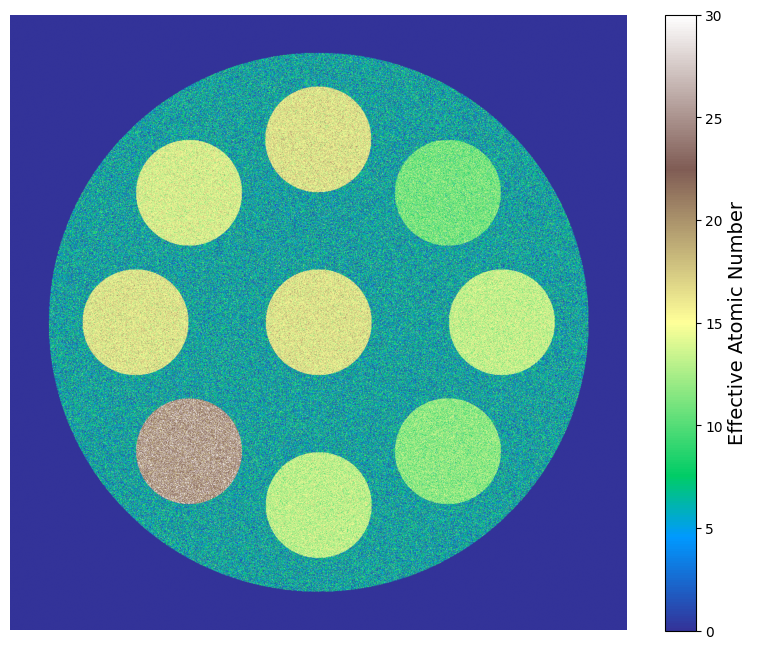

Minimum Zeff = 0.0
Maximum Zeff = 30.0
Calculating Electron Density map...
Electron Density calculation completed
ED map saved


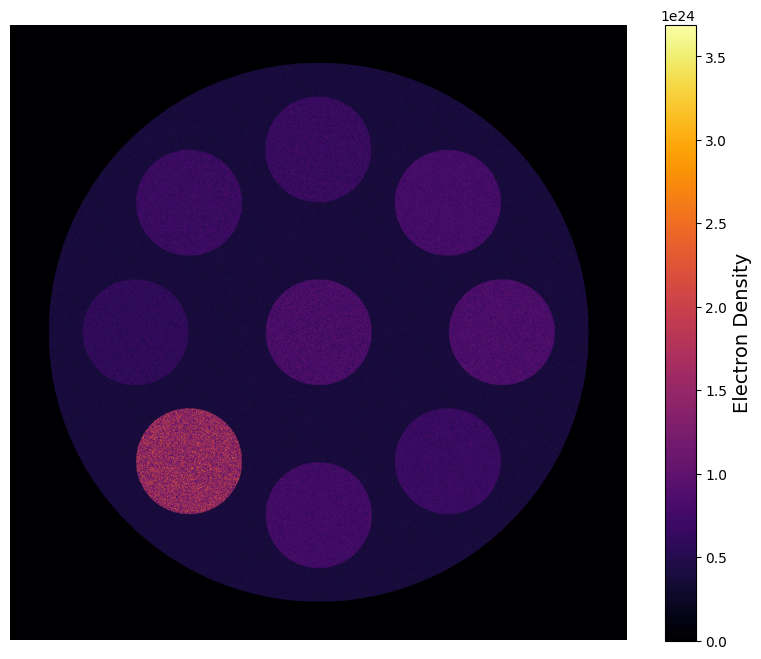

Mean ED = 3.1814E+23
Minimum ED = -0.0000E+00
Maximum ED = 3.6910E+24
R min: 0.4570721250140114
R max: 9.932728046260527
Ratio model at Z=5: 1.2241664188847385
Ratio model at Z=10: 1.7771825566067008
Ratio model at Z=20: 4.336808668260993


In [5]:
# @title
# =========================================================
# COMPLETE PIPELINE
# TIFF --> CALIBRATION --> FILTER --> Zeff --> ED
# =========================================================

import numpy as np
import matplotlib.pyplot as plt

from tifffile import imread, imwrite
from scipy.ndimage import median_filter

# =========================================================
# LOAD TIFF STACK
# Expected shape = (5, H, W)
# =========================================================

stack = imread(
    "/content/Rocks Synthetic Phantom.tiff"
).astype(np.float64)

print("Stack Shape:", stack.shape)

# =========================================================
# CALIBRATION COEFFICIENTS
# mu = A*x + B
# =========================================================

A = np.array([
    3.9658,
    1.8108,
    1.4754,
    1.3152,
    1.0269
], dtype=np.float64)

B = np.array([
   -0.5300,
   -0.1077,
   -0.0462,
   -0.0298,
   -0.0077
], dtype=np.float64)

# =========================================================
# APPLY CALIBRATION
# =========================================================

stack_mu = A[:, None, None] * stack + B[:, None, None]

print("Calibration Applied")

# =========================================================
# SAVE CALIBRATED STACK
# =========================================================

imwrite(
    "calibrated_image.tif",
    stack_mu.astype(np.float32)
)

print("Calibrated image saved")

# =========================================================
# SELECT ENERGY BINS
# E2 = LOW ENERGY
# E5 = HIGH ENERGY
# =========================================================

mu_low  = stack_mu[1]
mu_high = stack_mu[4]
print("mu_low min/max:", np.nanmin(mu_low), np.nanmax(mu_low))
print("mu_high min/max:", np.nanmin(mu_high), np.nanmax(mu_high))

# =========================================================
# REMOVE SALT-AND-PEPPER NOISE
# =========================================================

#mu_low  = median_filter(mu_low, size=3)
#mu_high = median_filter(mu_high, size=3)
#print("Noise filtering completed")

# =========================================================
# ENERGY VALUES
# =========================================================

E_low  = 45.136
E_high = 90.695

Fc_low  = 0.5697
Fc_high = 0.5038

# =========================================================
# MEASURED RATIO
# =========================================================

#R_measured = mu_low / (mu_high + 1e-8)
valid_mask = (mu_low > 0) & (mu_high > 0.01)

R_measured = np.full_like(mu_low, np.nan, dtype=np.float64)
R_measured[valid_mask] = mu_low[valid_mask] / mu_high[valid_mask]

print("Valid ratio min:", np.nanmin(R_measured))
print("Valid ratio max:", np.nanmax(R_measured))

# =========================================================
# THEORETICAL TOTAL CROSS-SECTION MODEL
# =========================================================

def sigma_total(Z, E, Fc):

    return (
        19.76 * (E ** (-3.03)) * (Z ** 4.28)
        + Fc * Z
        + 1.07 * (E ** (-1.76)) * (Z ** 2.79)
    )

# =========================================================
# RATIO MODEL
# =========================================================

def ratio_model(Z):

    numerator = sigma_total(
        Z,
        E_low,
        Fc_low
    )

    denominator = sigma_total(
        Z,
        E_high,
        Fc_high
    )

    return numerator / denominator

# =========================================================
# NUMERICAL DERIVATIVE
# =========================================================

def derivative_ratio(Z):

    dz = 1e-4

    return (
        ratio_model(Z + dz)
        - ratio_model(Z - dz)
    ) / (2 * dz)

# =========================================================
# INITIALIZE Zeff MAP
# =========================================================

H, W = R_measured.shape

Zeff_map = np.zeros((H, W), dtype=np.float32)

# =========================================================
# NEWTON-RAPHSON ITERATIVE SOLVER
# =========================================================

max_iter = 30
tolerance = 1e-5

print("Calculating Zeff map...")

for y in range(H):

    for x in range(W):

        r = R_measured[y, x]

        # Skip invalid pixels
        if np.isnan(r) or np.isinf(r):
            continue

        # Initial guess
        Z = 10.0

        for i in range(max_iter):

            f = ratio_model(Z) - r

            df = derivative_ratio(Z)

            # Prevent instability
            if abs(df) < 1e-10:
                break

            # Newton-Raphson update
            Z_new = Z - (f / df)

            # Physical constraints
            Z_new = np.clip(Z_new, 1, 30)

            # Convergence check
            if abs(Z_new - Z) < tolerance:
                Z = Z_new
                break

            Z = Z_new

        Zeff_map[y, x] = Z

print("Zeff Calculation Complete")

# =========================================================
# MAKE BACKGROUND BLACK
# =========================================================

threshold = 0.01

mask = mu_high > threshold

Zeff_map[~mask] = 0

# =========================================================
# SAVE Zeff MAP
# =========================================================

imwrite(
    "Rock_Phantom_Zeff_map.tif",
    Zeff_map.astype(np.float32)
)

print("Zeff map saved")

# =========================================================
# DISPLAY Zeff MAP
# =========================================================

plt.figure(figsize=(10,8))

plt.imshow(Zeff_map, cmap='terrain', vmin=0)

cbar1 = plt.colorbar(label='Effective Atomic Number')
cbar1.set_label('Effective Atomic Number', fontsize=14)

#plt.title('Zeff Map', fontsize=16,fontweight="bold")

plt.axis('off')

plt.show()

# =========================================================
# PRINT Zeff RANGE
# =========================================================

print("Minimum Zeff =", np.min(Zeff_map))
print("Maximum Zeff =", np.max(Zeff_map))

# =========================================================
# ELECTRON DENSITY (ED) CALCULATION
# Using High Energy Bin
# =========================================================

print("Calculating Electron Density map...")

# Use high-energy calibrated attenuation
mu_eff = mu_high

# =========================================================
# TOTAL CROSS SECTION PER PIXEL
# =========================================================

sigma = sigma_total(
    Zeff_map,
    E_high,
    Fc_high
)

# Prevent divide-by-zero
sigma = np.clip(
    sigma,
    1e-20,
    None
)

# =========================================================
# ELECTRON DENSITY FORMULATION
# =========================================================

# Step 1: Electron density term
ED = mu_eff / sigma

# Step 2: Multiply with Zeff
ED_map = ED * Zeff_map

# Step 3: Convert to absolute units
ED_map = ED_map * 1e24

print("Electron Density calculation completed")

# =========================================================
# SAVE ED MAP
# =========================================================

imwrite(
    "Rock_Phantom_ED_map.tif",
    ED_map.astype(np.float32)
)

print("ED map saved")

# =========================================================
# DISPLAY ED MAP
# =========================================================

plt.figure(figsize=(10,8))
plt.imshow(ED_map, cmap='inferno')
cbar2 = plt.colorbar(label='Electron Density')
cbar2.set_label('Electron Density', fontsize=14)
#plt.title('ED Map (electrons/cm³)', fontsize=16,fontweight="bold")
plt.axis('off')
plt.show()

# =========================================================
# PRINT ED RANGE
# =========================================================

print(
    "Mean ED = {:.4E}".format(
        np.nanmean(ED_map)
    )
)

print(
    "Minimum ED = {:.4E}".format(
        np.nanmin(ED_map)
    )
)

print(
    "Maximum ED = {:.4E}".format(
        np.nanmax(ED_map)
    )
)


print("R min:", np.nanmin(R_measured))
print("R max:", np.nanmax(R_measured))
print("Ratio model at Z=5:", ratio_model(5))
print("Ratio model at Z=10:", ratio_model(10))
print("Ratio model at Z=20:", ratio_model(20))